<img src="../resources/HTLstp-RGB150.png" alt="HTL" width=200>
REFR - Prof. Franz Reichel

DSAI - 4XHIF Klasse

---

# 📓 Diagramm-Manipulation Part 2:

## Request Data

In [7]:
import requests
import json

# CoinGecko API (kostenlose Variante, 2 Tage)
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
params = {"vs_currency": "usd", "days": 2}

response = requests.get(url, params=params)
data = response.json()

# Datei speichern (nur wenn "prices" enthalten)
#### if "prices" in data:
####     with open("../data/bitcoin_prices.json", "w") as f:
####         json.dump(data, f)
####     print("✅ Bitcoin-Daten gespeichert: bitcoin_prices.json")
#### else:
####     print("⚠️ Keine Preisdaten gefunden!")
####     print("Antwort:", data)

✅ Bitcoin-Daten gespeichert: bitcoin_prices.json


## Daten Auswertung

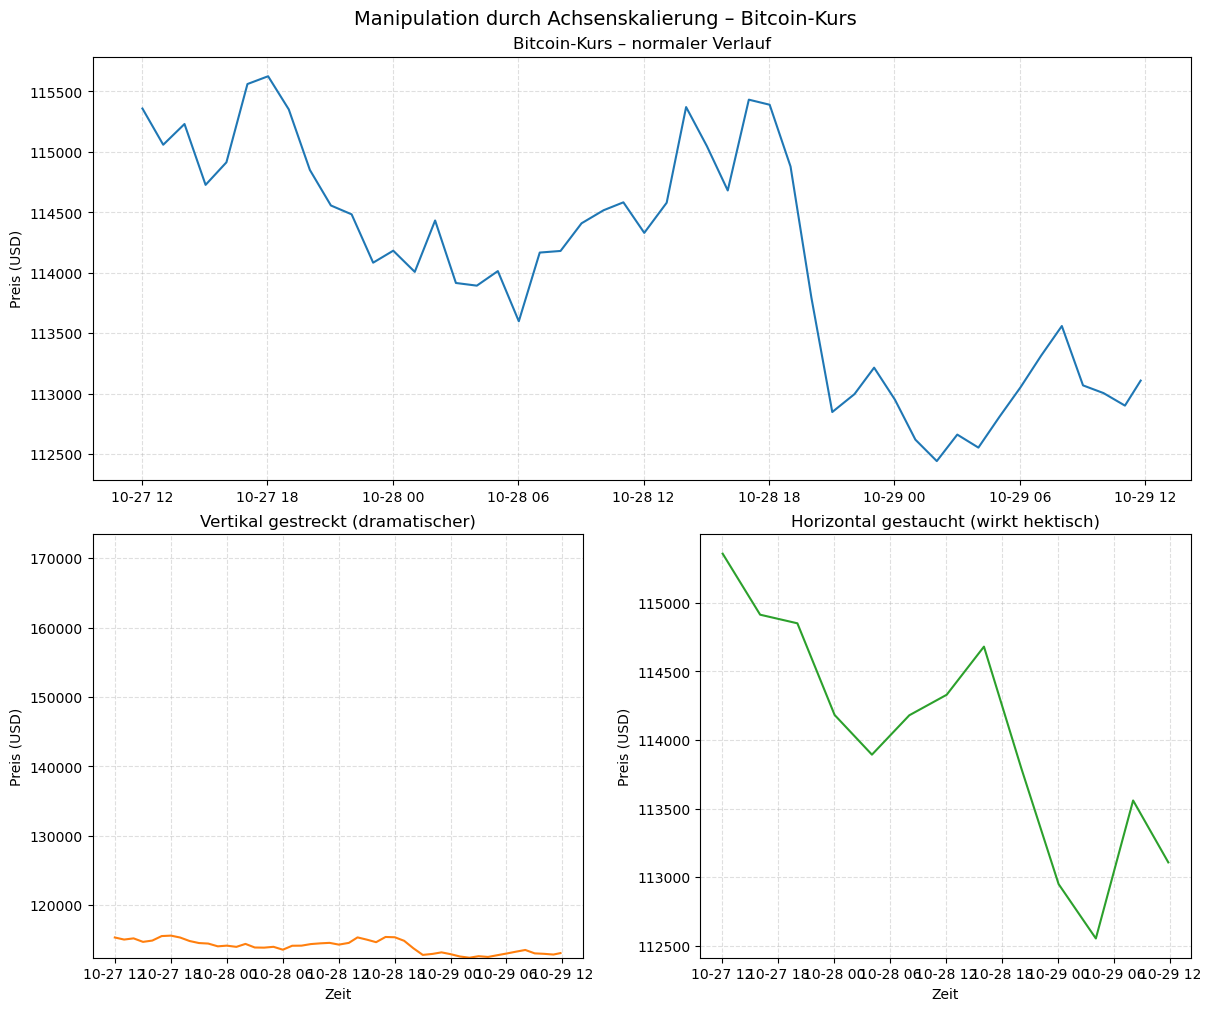

In [28]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# JSON laden
with open("../data/bitcoin_prices.json", "r") as f:
    data = json.load(f)

# DataFrame erzeugen
prices = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
prices["timestamp"] = pd.to_datetime(prices["timestamp"], unit="ms")

# Option: handlich kürzen
prices = prices.tail(50)

# Manipulierte Varianten
prices_stauched = prices.iloc[::4, :]  # horizontal gestaucht
prices_stretched = prices.copy()       # vertikal gestreckt

# Figure mit flexiblem Grid (2 Reihen, 2 Spalten)
fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

# -----------------------------
# 1️⃣ Normal (oben, über beide Spalten)
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(prices["timestamp"], prices["price"], color="tab:blue")
ax_top.set_title("Bitcoin-Kurs – normaler Verlauf", fontsize=12)
ax_top.set_xlabel("")
ax_top.set_ylabel("Preis (USD)")
ax_top.grid(True, linestyle="--", alpha=0.4)

# -----------------------------
# 2️⃣ Vertikal gestreckt (unten links)
ax_bottom_left = fig.add_subplot(gs[1, 0])
ax_bottom_left.plot(prices_stretched["timestamp"], prices_stretched["price"], color="tab:orange")
ax_bottom_left.set_title("Vertikal gestreckt (dramatischer)")
ax_bottom_left.set_xlabel("Zeit")
ax_bottom_left.set_ylabel("Preis (USD)")
# künstlich gestreckte Y-Achse
y_min, y_max = prices["price"].min(), prices["price"].max()
ax_bottom_left.set_ylim(y_min - (y_max - y_min)*0.5, y_max + (y_max - y_min)*0.5)
ax_bottom_left.set_ylim(prices["price"].min(), prices["price"].max() * 1.5)
ax_bottom_left.grid(True, linestyle="--", alpha=0.4)

# -----------------------------
# 3️⃣ Horizontal gestaucht (unten rechts)
ax_bottom_right = fig.add_subplot(gs[1, 1])
ax_bottom_right.plot(prices_stauched["timestamp"], prices_stauched["price"], color="tab:green")
ax_bottom_right.set_title("Horizontal gestaucht (wirkt hektisch)")
ax_bottom_right.set_xlabel("Zeit")
ax_bottom_right.set_ylabel("Preis (USD)")
ax_bottom_right.grid(True, linestyle="--", alpha=0.4)

# Gesamttitel
fig.suptitle("Manipulation durch Achsenskalierung – Bitcoin-Kurs", fontsize=14)

plt.style.use('default')
# plt.style.use('dark_background')
#plt.savefig("Crypto_manipulation_plot.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()



# BitCoin Kurse vom 29.10.2025

<img src="../resources/bitcoin_chart/BitCoin-Kurs-1Day-29102025.png" alt="29102025" width="50%">
<img src="../resources/bitcoin_chart/BitCoin-Kurs-6Month.png" alt="29102025" width="50%">
<img src="../resources/bitcoin_chart/BitCoin-Kurs-Max.png" alt="29102025" width="50%">